# Footstep Audio Classification using TSFresh Features

**Experiment 001**: Feature extraction, selection, and classification of bird footstep sounds.

## Pipeline Overview

1. **Data Consolidation** - Copy audio files to consolidated directory
2. **Feature Extraction** - TSFresh comprehensive features (parallel processing)
3. **Feature Selection** - FRESH statistical selection + train/test split
4. **Model Comparison** - Grid search across RF, XGB, SVM, MLP, kNN
5. **Statistical Analysis** - Friedman test + Nemenyi post-hoc + CD diagram
6. **RFE Feature Elimination** - Recursive elimination with CV
7. **Fine-tuning** - XGBoost optimization on reduced feature set
8. **Feature Importance** - Impurity, Permutation, SHAP analysis
9. **Final Evaluation** - Test set metrics and confusion matrix
10. **Export** - PDF figures, LaTeX tables, C code for deployment

In [1]:
# Setup: Add src to path and import modules
import sys
from pathlib import Path

# Add project root to path
PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

# Import project modules
from src import config, preprocessing, features, modeling, visualization

# Standard imports
import pandas as pd
import numpy as np
import json
import joblib

from sklearn.model_selection import train_test_split
import autorank
import matplotlib.pyplot as plt

# Create output directories
config.create_directories()

print(f"Project root: {config.PROJECT_ROOT}")
print(f"Data directory: {config.DATA_DIR}")
print(f"\n✓ All modules loaded")

Project root: /home/ubuntu-wsl/Projects/Dottorato/001_footsteps_rf
Data directory: /home/ubuntu-wsl/Projects/Dottorato/001_footsteps_rf/data

✓ All modules loaded


/home/ubuntu-wsl/miniconda3/envs/footfall-hcf/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
# Fix absolute paths in consolidated_summary.csv to current project directory
import shutil
import pandas as pd

orig = config.CONSOLIDATED_SUMMARY
backup = config.CONSOLIDATED_SUMMARY.with_suffix('.csv.bak')

if not orig.exists():
    print(f"Consolidated summary not found: {orig}")
else:
    # Backup original if not already backed up
    if not backup.exists():
        shutil.copy2(orig, backup)
        print(f"Backed up original consolidated summary to: {backup}")

    df = pd.read_csv(orig)
    # Rebuild paths using config.CONSOLIDATED_DIR and the filename column
    df['path'] = df['filename'].apply(lambda fn: str(config.CONSOLIDATED_DIR / fn))
    df.to_csv(orig, index=False)
    print(f"Rewrote paths in: {orig}")
    print(df.head())

Backed up original consolidated summary to: /home/ubuntu-wsl/Projects/Dottorato/001_footsteps_rf/data/interim/consolidated_summary.csv.bak
Rewrote paths in: /home/ubuntu-wsl/Projects/Dottorato/001_footsteps_rf/data/interim/consolidated_summary.csv
              filename                                               path  \
0  BB-1687970682-1.wav  /home/ubuntu-wsl/Projects/Dottorato/001_footst...   
1  BB-1687971323-1.wav  /home/ubuntu-wsl/Projects/Dottorato/001_footst...   
2  BB-1687971323-2.wav  /home/ubuntu-wsl/Projects/Dottorato/001_footst...   
3  BB-1687971360-1.wav  /home/ubuntu-wsl/Projects/Dottorato/001_footst...   
4  BB-1687971360-2.wav  /home/ubuntu-wsl/Projects/Dottorato/001_footst...   

   fold  target category  
0     3       0       BB  
1    10       0       BB  
2     2       0       BB  
3     5       0       BB  
4     2       0       BB  


## 1. Data Consolidation

Copy audio files from source directory to consolidated directory with flattened structure.

In [3]:
# Load summary and consolidate files
#summary_df = pd.read_csv(config.SUMMARY_CSV)
#print(f"Total samples: {len(summary_df)}")
#print(f"\nClass distribution:")
#print(summary_df['category'].value_counts())

# Consolidate (skip if already present)
if config.CONSOLIDATED_DIR.exists() and config.CONSOLIDATED_SUMMARY.exists():
    print(f"✓ Consolidation skipped - loading existing consolidated summary:\n  {config.CONSOLIDATED_SUMMARY}")
    consolidated_df = pd.read_csv(config.CONSOLIDATED_SUMMARY)
    try:
        n_files = len(list(config.CONSOLIDATED_DIR.glob("**/*")))
    except Exception:
        n_files = 'unknown'
    print(f"  Files in consolidated dir: {n_files}")
else:
    print("Consolidating audio files...")
    consolidated_df = preprocessing.consolidate_audio_files(summary_df)

    # Save consolidated summary
    consolidated_df.to_csv(config.CONSOLIDATED_SUMMARY, index=False)
    print(f"\n✓ Consolidated to: {config.CONSOLIDATED_SUMMARY}")

✓ Consolidation skipped - loading existing consolidated summary:
  /home/ubuntu-wsl/Projects/Dottorato/001_footsteps_rf/data/interim/consolidated_summary.csv
  Files in consolidated dir: 1686


## 2. Feature Extraction

Extract TSFresh comprehensive features using parallel processing.

In [5]:
# Extract features
if config.DATASET_RAW.exists():
    print(f"✓ Feature extraction skipped - loading existing file:")
    print(f"  {config.DATASET_RAW}")
    dataset_raw = pd.read_csv(config.DATASET_RAW)
    print(f"  Shape: {dataset_raw.shape}")
else:
    print("Extracting features...")
    dataset_raw = features.extract_all_features(consolidated_df, n_cpus=config.N_CPUS)

    # Save to interim
    dataset_raw.to_csv(config.DATASET_RAW, index=False)
    print(f"\n✓ Saved to: {config.DATASET_RAW}")

✓ Feature extraction skipped - loading existing file:
  /home/rpignelli/Projects/001_footsteps_rf/data/interim/exp01_consolidated_tsfresh_1_comprehensive.csv
  Shape: (1686, 785)


## 3. Dataset Cleaning

In [6]:
# Load and clean
dataset_raw = pd.read_csv(config.DATASET_RAW)
dataset_clean = preprocessing.clean_dataset(dataset_raw)

# Save
dataset_clean.to_csv(config.DATASET_CLEAN, index=False)
print(f"\n✓ Saved to: {config.DATASET_CLEAN}")

Original features: 783
  Removed 47 zero-variance features
Final features: 736

✓ Saved to: /home/rpignelli/Projects/001_footsteps_rf/data/processed/exp01_consolidated_tsfresh_1_comprehensive_clean.csv


## 4. FRESH Feature Selection

Apply statistical feature selection and create train/test split.

In [7]:
# Load cleaned dataset
dataset_clean = pd.read_csv(config.DATASET_CLEAN)

y = dataset_clean['target']
X = dataset_clean.drop(columns=['category', 'target'])

print(f"Original features: {X.shape[1]}")
print(f"Total samples: {len(X)}")

# 80/20 stratified split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=config.TEST_SIZE, stratify=y, random_state=config.RANDOM_STATE
)

print(f"\nTrain: {len(X_train)} samples")
print(f"Test: {len(X_test)} samples")

# FRESH selection
selected_features = features.apply_fresh_selection(X_train, y_train)

# Apply to train/test
X_train_selected = X_train[selected_features]
X_test_selected = X_test[selected_features]

# Rebuild with category
train_df = pd.DataFrame({'category': dataset_clean.loc[X_train.index, 'category'].values})
train_df = pd.concat([train_df, X_train_selected.reset_index(drop=True)], axis=1)
train_df['target'] = y_train.values

test_df = pd.DataFrame({'category': dataset_clean.loc[X_test.index, 'category'].values})
test_df = pd.concat([test_df, X_test_selected.reset_index(drop=True)], axis=1)
test_df['target'] = y_test.values

# Save
train_df.to_csv(config.FRESH_TRAIN, index=False)
test_df.to_csv(config.FRESH_TEST, index=False)

with open(config.FRESH_FEATURES, 'w') as f:
    f.write('\n'.join(selected_features))

print(f"\n✓ Saved train/test splits and feature list")

Original features: 736
Total samples: 1686

Train: 1348 samples
Test: 338 samples
Applying FRESH selection on 736 features...
✓ Selected 326 features (55.7% reduction)

✓ Saved train/test splits and feature list


## 5. Grid Search - Model Comparison

5-fold CV grid search for RF, XGB, SVM, MLP, kNN.

In [29]:
# Load data
train_df = pd.read_csv(config.FRESH_TRAIN)
test_df = pd.read_csv(config.FRESH_TEST)

X_train = train_df.drop(columns=['category', 'target']).values
y_train = train_df['target'].values
X_test = test_df.drop(columns=['category', 'target']).values
y_test = test_df['target'].values

print(f"Train: {X_train.shape}")
print(f"Test: {X_test.shape}\n")

# Run incremental grid search with extended parameter grids
# Skips combinations already in existing results
summary_df = modeling.run_incremental_grid_search(X_train, y_train, X_test, y_test)

print("\n" + "="*60)
print("Summary (sorted by CV score):")
print(summary_df[['model', 'best_cv_score', 'cv_std', 'test_score', 'n_combinations']].to_string(index=False))

Train: (1348, 326)
Test: (338, 326)



Incremental Grid Search:   0%|          | 0/4 [00:00<?, ?it/s]


RF: 243 existing, 2700 new of 2700 total combinations
Fitting 5 folds for each of 2700 candidates, totalling 13500 fits


Incremental Grid Search:  25%|██▌       | 1/4 [1:19:03<3:57:09, 4743.14s/it]

  Best CV: 0.8173, Test: 0.8491
  Total combinations now: 2943

SVM: 20 existing, 528 new of 528 total combinations
Fitting 5 folds for each of 528 candidates, totalling 2640 fits


...

  Best CV: 0.8075, Test: 0.8462
  Total combinations now: 548

MLP: 96 existing, 1000 new of 1000 total combinations
Fitting 5 folds for each of 1000 candidates, totalling 5000 fits


/home/rpignelli/miniconda3/envs/footfall/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/rpignelli/miniconda3/envs/footfall/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/rpignelli/miniconda3/envs/footfall/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/rpignelli/miniconda3/envs/footfall/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization

  Best CV: 0.8106, Test: 0.8343
  Total combinations now: 1096

kNN: 56 existing, 750 new of 750 total combinations
Fitting 5 folds for each of 750 candidates, totalling 3750 fits


Incremental Grid Search: 100%|██████████| 4/4 [1:48:10<00:00, 1622.63s/it]

  Best CV: 0.7350, Test: 0.7663
  Total combinations now: 806

Summary (sorted by CV score):
model  best_cv_score   cv_std  test_score  n_combinations
  XGB       0.830426 0.016409    0.830440            1296
   RF       0.817282 0.017094    0.849112            2943
  MLP       0.810557 0.029753    0.834320            1096
  SVM       0.807517 0.023684    0.846154             548
  kNN       0.734989 0.016410    0.766272             806


## 6. Statistical Model Comparison

Friedman test and Nemenyi post-hoc analysis.

In [30]:
# Load fold scores
fold_scores = modeling.load_fold_scores()

# Print fold scores
print("CV Fold Scores:")
for model, scores in fold_scores.items():
    print(f"  {model}: {np.mean(scores):.4f} ± {np.std(scores):.4f}")

# Run statistical comparison
stats_results = modeling.run_statistical_comparison(fold_scores)

CV Fold Scores:
  RF: 0.8173 ± 0.0171
  XGB: 0.8304 ± 0.0164
  SVM: 0.8075 ± 0.0237
  MLP: 0.8106 ± 0.0298
  kNN: 0.7350 ± 0.0164
Friedman test: χ² = 14.2400, p = 0.006567
Significant: True

Model Rankings:
Model  Mean_CV_Score  Std_CV_Score  Average_Rank
  XGB       0.830426      0.016409           2.4
   RF       0.817282      0.017094           3.4
  MLP       0.810557      0.029753           3.8
  SVM       0.807517      0.023684           4.4
  kNN       0.734989      0.016410           6.0


## 7. Critical Difference Diagram

     meanrank      mean       std ci_lower ci_upper effect_size   magnitude  \
kNN       5.0  0.734989  0.018347      NaN      NaN         0.0  negligible   
SVM       3.4  0.807517  0.026480      NaN      NaN   -3.183933       large   
MLP       2.8  0.810557  0.033265      NaN      NaN   -2.813159       large   
RF        2.4  0.817282  0.019112      NaN      NaN   -4.392896       large   
XGB       1.4  0.830426  0.018346      NaN      NaN   -5.201934       large   

    effect_size_above magnitude_above  
kNN               0.0      negligible  
SVM         -3.183933           large  
MLP         -0.101136      negligible  
RF          -0.247886           small  
XGB         -0.701652          medium  


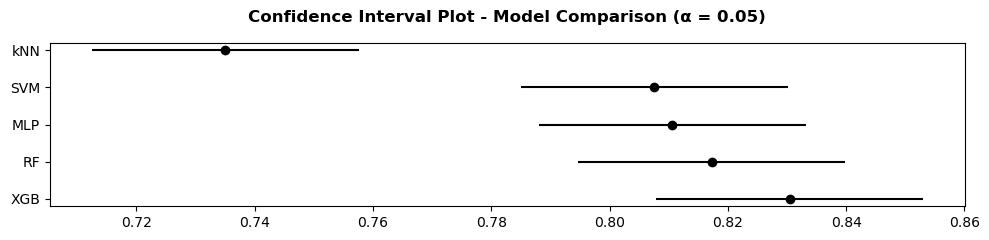

✓ Saved: /home/rpignelli/Projects/001_footsteps_rf/results/latex_figures/confidence_interval_plot.pdf

RankResult(rankdf=
     meanrank      mean       std  ci_lower  ci_upper effect_size   magnitude  \
kNN       5.0  0.734989  0.018347  0.712412  0.757566         0.0  negligible   
SVM       3.4  0.807517  0.026480   0.78494  0.830094   -3.183933       large   
MLP       2.8  0.810557  0.033265   0.78798  0.833134   -2.813159       large   
RF        2.4  0.817282  0.019112  0.794705  0.839859   -4.392896       large   
XGB       1.4  0.830426  0.018346  0.807849  0.853003   -5.201934       large   

    effect_size_above magnitude_above  
kNN               0.0      negligible  
SVM         -3.183933           large  
MLP         -0.101136      negligible  
RF          -0.247886           small  
XGB         -0.701652          medium  
pvalue=6.177897203863261e-08
cd=None
omnibus=anova
posthoc=tukeyhsd
all_normal=True
pvals_shapiro=[np.float64(0.7536226827976618), np.float64(0.5160939

In [33]:
# Generate CD diagram with autorank
score_df = stats_results['fold_scores']

result = autorank.autorank(score_df, alpha=0.05, verbose=False, order='descending')

fig, ax = plt.subplots(figsize=(10, 2.5))
autorank.plot_stats(result, ax=ax, allow_insignificant=True)
plt.title('Confidence Interval Plot - Model Comparison (α = 0.05)', fontsize=12, fontweight='bold', pad=15)
plt.tight_layout()

# Save
cd_path = config.LATEX_FIGURES_DIR / "confidence_interval_plot.pdf"
plt.savefig(cd_path, format='pdf', bbox_inches='tight', dpi=300)
plt.show()

print(f"✓ Saved: {cd_path}")
print("\n" + "="*60)
print(result)

## 8. RFE Feature Elimination

Recursive Feature Elimination to find optimal feature subset.

In [11]:
# Load data
train_df = pd.read_csv(config.FRESH_TRAIN)
X_train = train_df.drop(columns=['category', 'target'])
y_train = train_df['target'].values
feature_names = list(X_train.columns)

print(f"Features: {len(feature_names)}")

# Run RFE
ranking_df = modeling.run_rfe_elimination(X_train.values, y_train, feature_names)
ordered_features = ranking_df['feature'].tolist()

# Evaluate k-path
k_path_df, k_summary = modeling.evaluate_k_path(X_train, y_train, ordered_features)

# Select optimal k
k_selection = modeling.select_optimal_k(k_summary)

# Save feature lists
for method, k in [('best', k_selection['best_k']), ('1se', k_selection['k_1se']), 
                  ('friedman', k_selection['k_friedman'])]:
    features_k = ordered_features[:k]
    with open(config.RFE_DIR / f"rfe_features_{method}_k{k}.txt", 'w') as f:
        f.write('\n'.join(features_k))

print(f"\n✓ Feature lists saved")

Features: 326
Fitting RFE for 326 features...
✓ RFE complete. Top 10 features:
    1. value__autocorrelation__lag_3
    2. value__friedrich_coefficients__coeff_2__m_3__r_30
    3. value__sum_of_reoccurring_values
    4. value__autocorrelation__lag_6
    5. value__sum_of_reoccurring_data_points
    6. value__agg_autocorrelation__f_agg_"mean"__maxlag_4
    7. value__augmented_dickey_fuller__attr_"teststat"__a
    8. value__fft_aggregated__aggtype_"centroid"
    9. value__spkt_welch_density__coeff_8
   10. value__autocorrelation__lag_4


K-path: 100%|██████████| 326/326 [34:23<00:00,  6.33s/it]

Best k: 36 (score: 0.8372)
1-SE k: 17 (score: 0.8265)
Friedman k: 4 (score: 0.6997)

✓ Feature lists saved


## 9. XGBoost Fine-tuning

Optimize XGBoost on reduced feature set (1-SE rule).

In [12]:
# Select k based on 1-SE rule
SELECTED_K = k_selection['k_1se']
selected_features = ordered_features[:SELECTED_K]

print(f"Selected k: {SELECTED_K} features")

# Prepare data
train_df = pd.read_csv(config.FRESH_TRAIN)
test_df = pd.read_csv(config.FRESH_TEST)

X_train_k = train_df[selected_features].values
y_train = train_df['target'].values
X_test_k = test_df[selected_features].values
y_test = test_df['target'].values

print(f"Training shape: {X_train_k.shape}")
print(f"Test shape: {X_test_k.shape}\n")

# Fine-tune
finetuned_model, finetune_results = modeling.finetune_xgb(
    X_train_k, y_train, X_test_k, y_test, SELECTED_K
)

# Save selected features
with open(config.FINETUNE_DIR / f"selected_features_k{SELECTED_K}.txt", 'w') as f:
    f.write('\n'.join(selected_features))

Selected k: 17 features
Training shape: (1348, 17)
Test shape: (338, 17)

Fitting 5 folds for each of 864 candidates, totalling 4320 fits
✓ Fine-tuned XGB k=17: CV=0.8322, Test=0.8392


## 10. Statistical Comparison: Original vs Fine-tuned

In [13]:
# Load original XGBoost fold scores
with open(config.GRID_SEARCH_DIR / "XGB_fold_statistics.json", 'r') as f:
    original_xgb = json.load(f)

original_fold_scores = [original_xgb[f'split{i}_test_score'] for i in range(5)]
finetune_fold_scores = finetune_results['fold_scores']

# Comparison
wilcoxon_result = modeling.compare_models_wilcoxon(
    original_fold_scores, finetune_fold_scores,
    "Original XGB (326 features)", f"Fine-tuned XGB ({SELECTED_K} features)"
)

# Save comparison
comparison_results = {
    'original_xgb': {
        'mean_cv_score': np.mean(original_fold_scores),
        'std_cv_score': np.std(original_fold_scores),
        'n_features': len(train_df.columns) - 2,
        'n_estimators': original_xgb['best_params'].get('clf__n_estimators', 1000)
    },
    'finetuned_xgb': {
        'mean_cv_score': np.mean(finetune_fold_scores),
        'std_cv_score': np.std(finetune_fold_scores),
        'n_features': SELECTED_K,
        'n_estimators': finetune_results['best_params'].get('clf__n_estimators', 100)
    },
    'wilcoxon_test': wilcoxon_result
}

with open(config.FINETUNE_DIR / "comparison_results.json", 'w') as f:
    json.dump(comparison_results, f, indent=2)

print(f"\n✓ Comparison saved")

Wilcoxon test: Original XGB (326 features) vs Fine-tuned XGB (17 features)
  Statistic: 5.0000, p-value: 0.6250
  Original XGB (326 features): 0.8304 ± 0.0164
  Fine-tuned XGB (17 features): 0.8322 ± 0.0307
  Significant: False

✓ Comparison saved


## 11. Feature Importance Analysis

Impurity, Permutation, and SHAP importance.

In [14]:
# Load model and data
finetuned_model = joblib.load(config.FINETUNE_DIR / f"xgb_finetuned_k{SELECTED_K}.pkl")

train_df = pd.read_csv(config.FRESH_TRAIN)
test_df = pd.read_csv(config.FRESH_TEST)

X_train_k = train_df[selected_features].values
X_test_k = test_df[selected_features].values
y_test = test_df['target'].values

# Get class names
class_mapping = train_df[['category', 'target']].drop_duplicates().set_index('target')['category'].to_dict()
class_names = [class_mapping[i] for i in sorted(class_mapping.keys())]

# Humanize feature names
humanized_features = features.humanize_feature_names(selected_features)

print(f"Model: Fine-tuned XGBoost with {SELECTED_K} features")
print(f"Classes: {class_names}")

# Compute importance analysis
importance_results = modeling.compute_importance_analysis(
    finetuned_model, X_train_k, X_test_k, y_test,
    selected_features, humanized_features, class_names
)

print(f"\n✓ All importance results saved to: {config.IMPORTANCE_DIR}")

Model: Fine-tuned XGBoost with 17 features
Classes: ['BB', 'C', 'GW', 'WTD']
✓ Impurity importance computed
✓ Permutation importance computed
✓ SHAP analysis computed

Rank correlations:
  Impurity vs Permutation: ρ = 0.341 (p = 0.1809)
  Impurity vs SHAP: ρ = 0.679 (p = 0.0027)
  Permutation vs SHAP: ρ = 0.706 (p = 0.0015)

✓ All importance results saved to: /home/rpignelli/Projects/001_footsteps_rf/results/feature_importance


## 12. Final Evaluation on Test Set

In [15]:
# Final evaluation
final_results = modeling.evaluate_final_model(
    finetuned_model, X_test_k, y_test, class_names
)

print(f"\n✓ Final metrics saved to: {config.PROCESSED_DIR}")


Final Test Results:
  Accuracy: 0.8580
  F1 (Macro): 0.8392

              precision    recall  f1-score   support

          BB       0.84      0.84      0.84        96
           C       0.89      0.87      0.88        63
          GW       0.87      0.93      0.90       130
         WTD       0.80      0.67      0.73        49

    accuracy                           0.86       338
   macro avg       0.85      0.83      0.84       338
weighted avg       0.86      0.86      0.86       338


✓ Final metrics saved to: /home/rpignelli/Projects/001_footsteps_rf/data/processed


## 13. SHAP Beeswarm Plots (Per Class)

In [16]:
# Generate beeswarm plots
scaler = finetuned_model.named_steps['scaler']
X_test_scaled = scaler.transform(X_test_k)

shap_values = importance_results['shap_values']
explainer = importance_results['explainer']

figs = visualization.plot_shap_beeswarm(
    shap_values, explainer, X_test_scaled, humanized_features, class_names
)

print(f"\n✓ Generated {len(figs)} beeswarm plots")


✓ Generated 4 beeswarm plots


## 14. Export All PDF Figures

In [17]:
# Export all figures from saved data
export_results = visualization.export_all_figures()

Loading saved data...
  ✓ k_path_cv.pdf
  ✓ full_k_path_cv.pdf
  ✓ impurity_importance.pdf
  ✓ permutation_importance.pdf
  ✓ shap_importance_bar.pdf
  ✓ ranking_comparison.pdf
  ✓ confusion_matrix_counts.pdf
  ✓ confusion_matrix_normalized.pdf
  ✓ shap_importance_by_class.pdf

✓ Exported 9/9 figures to /home/rpignelli/Projects/001_footsteps_rf/results/latex_figures


## 15. Export LaTeX Tables

In [18]:
# Prepare grid results for LaTeX export
test_df = pd.read_csv(config.FRESH_TEST)
class_names = sorted(test_df['category'].unique())

# Load features
with open(config.FINETUNE_DIR / f"selected_features_k{SELECTED_K}.txt", 'r') as f:
    features_k = [line.strip() for line in f.readlines()]

# Evaluate model
model = joblib.load(config.FINETUNE_DIR / f"xgb_finetuned_k{SELECTED_K}.pkl")
X_test_k = test_df[features_k].values
y_test = test_df['target'].values
y_pred = model.predict(X_test_k)

metrics, cm, per_class = modeling.compute_all_metrics(y_test, y_pred, class_names)

grid_results = {
    f'XGB_k{SELECTED_K}_finetuned': {
        'metrics': metrics,
        'cm': cm,
        'per_class': per_class,
        'class_names': class_names
    }
}

# Export
exported = visualization.export_latex_tables(grid_results)
print(f"\n✓ Exported {len(exported)} LaTeX files")

  ✓ model_comparison.csv/.tex
  ✓ per_class_xgb_k17_finetuned.tex, confusion_matrix_xgb_k17_finetuned.tex

✓ Exported 4 LaTeX files


## 16. Export XGBoost to C Code

In [19]:
# Export to C code using tl2cgen
size_df = visualization.export_models_to_c(SELECTED_K)

if not size_df.empty:
    print("\nModel size comparison:")
    print(size_df.to_string(index=False))
    print(f"\n✓ C code exported to: {config.TL2CGEN_DIR}")

[19:42:44] /project/src/compiler/ast/split.cc:30: Parallel compilation disabled; all member trees will be dumped to a single source file. This may increase compilation time and memory usage.
✓ Exported xgb_k17_finetuned: 868.22 KB, 23,691 lines

Model size comparison:
               Model  C Code Size (KB)  C Code Lines  n_estimators  max_depth
XGB k17 (fine-tuned)        868.223633         23691           100          7

✓ C code exported to: /home/rpignelli/Projects/001_footsteps_rf/results/tl2cgen_export


[19:42:44] /tmp/tmpfk5q71dd/libbuild/_deps/treelite-src/src/serializer.cc:202: The model you are loading originated from a newer Treelite version; some functionalities may be unavailable.
Currently running Treelite version 4.1.2
The model checkpoint was generated from Treelite version 4.6.1


## 17. Soft-Voting Ensemble (XGB + RF + SVM)

Soft-voting ensemble combining the three best single classifiers using the k=17 RFE feature set.
Best hyperparameters are loaded from the existing grid search results.

In [ ]:
import json
import numpy as np
import pandas as pd
from sklearn.ensemble import VotingClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold

# ── Load data ────────────────────────────────────────────────────────────────
train_df = pd.read_csv(config.FRESH_TRAIN)
test_df  = pd.read_csv(config.FRESH_TEST)

with open(config.FINETUNE_DIR / "selected_features_k17.txt") as f:
    features_k17 = [l.strip() for l in f if l.strip()]

X_train_k = train_df[features_k17].values
y_train   = train_df["target"].values
X_test_k  = test_df[features_k17].values
y_test    = test_df["target"].values

# Create sorted list of all class labels and corresponding names
all_classes = np.unique(y_train)
class_mapping = train_df[["category", "target"]].drop_duplicates().set_index("target")["category"].to_dict()
class_names = [class_mapping[int(c)] for c in all_classes]

# ── Load best params ─────────────────────────────────────────────────────────
# XGB: use fine-tuned results (k=17)
with open(config.FINETUNE_DIR / "xgb_finetuned_k17_results.json") as f:
    xgb_stats = json.load(f)
# strip 'clf__' prefix if present
xgb_params = {k.replace("clf__", ""): v for k, v in xgb_stats.get("best_params", {}).items()}

# RF and SVM: use grid search best params
def load_best_params_grid(model_name: str) -> dict:
    path = config.GRID_SEARCH_DIR / f"{model_name}_fold_statistics.json"
    with open(path) as f:
        stats = json.load(f)
    return {k.replace("clf__", ""): v for k, v in stats["best_params"].items()}

rf_params  = load_best_params_grid("RF")
svm_params = load_best_params_grid("SVM")
svm_params["probability"] = True   # required for soft voting

# Number of folds
skf = StratifiedKFold(n_splits=config.CV_FOLDS, shuffle=True, random_state=config.RANDOM_STATE)

# Storage for per-fold results
per_fold_metrics = []
probas_aligned = []  # will hold (n_test, n_classes) arrays aligned to all_classes

print(f"Running {config.CV_FOLDS}-fold CV training and evaluating on test set (k={len(features_k17)})...")

for fold_idx, (train_idx, _) in enumerate(skf.split(X_train_k, y_train)):
    print(f"\nFold {fold_idx+1}/{config.CV_FOLDS}")
    X_tr = X_train_k[train_idx]
    y_tr = y_train[train_idx]

    # Build fresh estimators for this fold
    xgb_est = XGBClassifier(**xgb_params, random_state=config.RANDOM_STATE, eval_metric="logloss")
    rf_est  = RandomForestClassifier(**rf_params, random_state=config.RANDOM_STATE)
    svm_est = SVC(**svm_params, random_state=config.RANDOM_STATE)

    voting_clf = VotingClassifier(
        estimators=[("xgb", xgb_est), ("rf", rf_est), ("svm", svm_est)],
        voting="soft",
        n_jobs=-1
    )
    pipeline = Pipeline([("scaler", StandardScaler()), ("clf", voting_clf)])

    # Fit on fold's training split
    pipeline.fit(X_tr, y_tr)

    # Predict probabilities on the held-out test set
    clf = pipeline.named_steps["clf"]
    proba = clf.predict_proba(pipeline.named_steps["scaler"].transform(X_test_k))
    fold_classes = clf.classes_

    # Align proba columns to all_classes ordering
    n_test = X_test_k.shape[0]
    n_classes = len(all_classes)
    aligned = np.zeros((n_test, n_classes), dtype=float)
    for col_idx, cls in enumerate(fold_classes):
        # find index in all_classes
        target_col = int(np.where(all_classes == cls)[0][0])
        aligned[:, target_col] = proba[:, col_idx]

    probas_aligned.append(aligned)

    # Per-fold hard predictions on test set
    y_pred_fold = np.argmax(aligned, axis=1)

    # Compute metrics for this fold
    m, cm_fold, per_class = modeling.compute_all_metrics(y_test, y_pred_fold, class_names)
    m_row = {"fold": fold_idx+1, **m}
    per_fold_metrics.append(m_row)

    print(f"  Fold Test F1 (Macro): {m['F1 (Macro)']:.4f}")

# ── Aggregate across folds ────────────────────────────────────────────────────
probas_mean = np.mean(np.stack(probas_aligned, axis=0), axis=0)  # (n_test, n_classes)

y_pred_mean = np.argmax(probas_mean, axis=1)

metrics_mean, cm_mean, per_class_mean = modeling.compute_all_metrics(y_test, y_pred_mean, class_names)

print(f"\nAggregated Test Results (averaged probabilities):")
print(f"  Accuracy      : {metrics_mean['Accuracy']:.4f}")
print(f"  Balanced Acc. : {metrics_mean['Balanced Accuracy']:.4f}")
print(f"  F1 (Macro)    : {metrics_mean['F1 (Macro)']:.4f}")

# Compare with fine-tuned XGB baseline
with open(config.FINETUNE_DIR / "xgb_finetuned_k17_results.json") as f:
    xgb_baseline = json.load(f)
xgb_f1 = xgb_baseline.get("test_score", None)
if xgb_f1 is not None:
    delta = metrics_mean["F1 (Macro)"] - xgb_f1
    print(f"Fine-tuned XGB k=17 F1 (Macro): {xgb_f1:.4f}")
    print(f"Ensemble F1 (Macro)           : {metrics_mean['F1 (Macro)']:.4f}  (Δ {delta:+.4f})")

# ── Save per-fold and aggregated results ──────────────────────────────────────
config.ENSEMBLE_DIR.mkdir(parents=True, exist_ok=True)

per_fold_df = pd.DataFrame(per_fold_metrics)
per_fold_df.to_csv(config.ENSEMBLE_DIR / "ensemble_per_fold_metrics.csv", index=False)

agg_df = pd.DataFrame({"Metric": list(metrics_mean.keys()), "Value": list(metrics_mean.values())})
agg_df.to_csv(config.ENSEMBLE_DIR / "ensemble_aggregated_metrics.csv", index=False)

cm_df = pd.DataFrame(cm_mean, index=class_names, columns=class_names)
cm_df.index.name = "True"
cm_df.to_csv(config.ENSEMBLE_DIR / "ensemble_confusion_matrix.csv")

print(f"\n✓ Saved ensemble per-fold and aggregated results to: {config.ENSEMBLE_DIR}")

Running 5-fold CV training and evaluating on test set (k=17)...

Fold 1/5
  Fold Test F1 (Macro): 0.8553

Fold 2/5
  Fold Test F1 (Macro): 0.8309

Fold 3/5
  Fold Test F1 (Macro): 0.8305

Fold 4/5
  Fold Test F1 (Macro): 0.8427

Fold 5/5
  Fold Test F1 (Macro): 0.8023

Aggregated Test Results (averaged probabilities):
  Accuracy      : 0.8639
  Balanced Acc. : 0.8305
  F1 (Macro)    : 0.8406
Fine-tuned XGB k=17 F1 (Macro): 0.8392
Ensemble F1 (Macro)           : 0.8406  (Δ +0.0014)

✓ Saved ensemble per-fold and aggregated results to: /home/ubuntu-wsl/Projects/Dottorato/001_footsteps_rf/results/ensemble


## 18. Conformal Prediction (MAPIE — CrossConformalClassifier)

Uncertainty quantification using cross-conformal prediction on the fine-tuned XGBoost (k=17).

- **CrossConformalClassifier** uses 5-fold CV internally to estimate conformity scores from out-of-fold predictions — no separate calibration split required, all 1348 training samples are used.
- **Prediction sets** replace single-label outputs: each test sample receives a set of plausible classes.
- **"Uncertain" prediction** when set size ≠ 1 (0 = very uncertain, >1 = ambiguous between classes).
- Evaluated across three confidence levels (α = 0.10, 0.05, 0.01) with both **LAC** and **APS** conformity scores.

In [19]:
import json
import numpy as np
import pandas as pd
from importlib import reload
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    confusion_matrix,
    classification_report,
)
from xgboost import XGBClassifier
from mapie.classification import CrossConformalClassifier

# Reload config to pick up CONFORMAL_DIR if it was added after initial import
reload(config)

# ── Load data & features ──────────────────────────────────────────────────────
train_df = pd.read_csv(config.FRESH_TRAIN)
test_df  = pd.read_csv(config.FRESH_TEST)

with open(config.FINETUNE_DIR / "selected_features_k17.txt") as f:
    features_k17 = [l.strip() for l in f if l.strip()]

X_train_k = train_df[features_k17].values
y_train   = train_df["target"].values
X_test_k  = test_df[features_k17].values
y_test    = test_df["target"].values
n_test    = len(y_test)

# map target -> name
class_mapping = train_df[["category", "target"]].drop_duplicates().set_index("target")["category"].to_dict()

# ── Load fine-tuned XGB best params ───────────────────────────────────────────
with open(config.FINETUNE_DIR / "xgb_finetuned_k17_results.json") as f:
    xgb_stats = json.load(f)
xgb_params = {k.replace("clf__", ""): v for k, v in xgb_stats.get("best_params", {}).items()}

def make_xgb_pipeline() -> Pipeline:
    return Pipeline([
        ("scaler", StandardScaler()),
        ("clf", XGBClassifier(**xgb_params, random_state=config.RANDOM_STATE, eval_metric="logloss")),
    ])

CONFIDENCE_LEVELS = [0.90, 0.95, 0.99]
SCORE_METHODS     = {"LAC": "lac", "APS": "aps"}

all_rows      = []   # summary-level rows (1 per method × confidence)
detailed_rows = []   # per-class rows     (n_classes per method × confidence)

config.CONFORMAL_DIR.mkdir(parents=True, exist_ok=True)

for score_name, score_str in SCORE_METHODS.items():
    print(f"\n{'='*55}\n  Conformity score: {score_name}\n{'='*55}")

    for conf_level in CONFIDENCE_LEVELS:
        alpha = 1.0 - conf_level

        mapie = CrossConformalClassifier(
            estimator=make_xgb_pipeline(),
            confidence_level=conf_level,
            conformity_score=score_str,
            cv=config.CV_FOLDS,
            random_state=config.RANDOM_STATE,
        )
        mapie.fit_conformalize(X_train_k, y_train)

        y_pred_mapie, y_pred_set = mapie.predict_set(X_test_k)
        set_mask  = y_pred_set[:, :, 0]
        set_sizes = set_mask.sum(axis=1)

        # ── Get class order used by MAPIE ─────────────────────────────────
        classes_ = getattr(mapie, "classes_", None)
        if classes_ is None:
            classes_ = getattr(mapie, "_mapie_classifier").classes_
        classes_ = np.asarray(classes_)

        class_to_col = {c: i for i, c in enumerate(classes_)}
        y_col = np.array([class_to_col[c] for c in y_test])
        cls_names = [class_mapping.get(int(c), str(c)) for c in classes_]

        # ── Summary metrics ───────────────────────────────────────────────
        coverage      = float(np.mean(set_mask[np.arange(n_test), y_col]))
        mean_set_size = float(set_sizes.mean())
        n_empty       = int((set_sizes == 0).sum())
        n_single      = int((set_sizes == 1).sum())
        n_multi       = int((set_sizes >  1).sum())

        confident_mask  = (set_sizes == 1)
        abstention_rate = 1.0 - (n_single / n_test)

        # Recover predicted class from the set (argmax safe for singletons)
        y_pred_from_set = classes_[set_mask.argmax(axis=1)]

        # ── Selective evaluation (singletons only) ────────────────────────
        if n_single > 0:
            selective_acc = float(accuracy_score(
                y_test[confident_mask], y_pred_from_set[confident_mask]))
            selective_macro_f1 = float(f1_score(
                y_test[confident_mask], y_pred_from_set[confident_mask],
                labels=classes_, average="macro", zero_division=0))

            cm_selective = confusion_matrix(
                y_test[confident_mask], y_pred_from_set[confident_mask],
                labels=classes_)

            # Classification report as dict → per-class rows
            report = classification_report(
                y_test[confident_mask], y_pred_from_set[confident_mask],
                labels=classes_, target_names=cls_names,
                output_dict=True, zero_division=0)

            print(f"\n  α = {alpha:.2f}  (confidence = {conf_level:.0%})")
            print(classification_report(
                y_test[confident_mask], y_pred_from_set[confident_mask],
                labels=classes_, target_names=cls_names, zero_division=0))

            # Collect per-class detail
            for cn in cls_names:
                if cn in report:
                    detailed_rows.append({
                        "method":           score_name,
                        "confidence_level": conf_level,
                        "alpha":            round(alpha, 2),
                        "class":            cn,
                        "precision":        round(report[cn]["precision"], 4),
                        "recall":           round(report[cn]["recall"], 4),
                        "f1_score":         round(report[cn]["f1-score"], 4),
                        "support":          int(report[cn]["support"]),
                    })
        else:
            selective_acc      = float("nan")
            selective_macro_f1 = float("nan")
            cm_selective       = None

        # ── Confusion matrix with ABSTAIN column ──────────────────────────
        ABSTAIN = -1
        y_pred_with_abstain = y_pred_from_set.copy()
        y_pred_with_abstain[~confident_mask] = ABSTAIN
        labels_with_abstain = np.append(classes_, ABSTAIN)

        cm_with_abstain = confusion_matrix(
            y_test, y_pred_with_abstain, labels=labels_with_abstain)

        # ── Print summary ─────────────────────────────────────────────────
        print(f"  Coverage: {coverage:.4f} | Abstention: {abstention_rate:.4f} | "
              f"Selective Acc: {selective_acc:.4f} | Selective Macro-F1: {selective_macro_f1:.4f}")
        print("  CM (singletons only):\n", cm_selective)
        print("  CM (with abstain):\n", cm_with_abstain)

        # ── Save confusion matrices per config ────────────────────────────
        tag = f"{score_name.lower()}_{int(conf_level * 100)}"

        if cm_selective is not None:
            pd.DataFrame(cm_selective, index=cls_names, columns=cls_names).to_csv(
                config.CONFORMAL_DIR / f"cm_selective_{tag}.csv", index_label="True")

        cls_names_ext = cls_names + ["Abstain"]
        pd.DataFrame(cm_with_abstain, index=cls_names_ext, columns=cls_names_ext).to_csv(
            config.CONFORMAL_DIR / f"cm_with_abstain_{tag}.csv", index_label="True")

        # ── Append summary row ────────────────────────────────────────────
        all_rows.append({
            "method":             score_name,
            "confidence_level":   conf_level,
            "alpha":              round(alpha, 4),
            "coverage":           round(coverage, 4),
            "mean_set_size":      round(mean_set_size, 4),
            "n_empty":            n_empty,
            "n_singleton":        n_single,
            "n_multi":            n_multi,
            "abstention_rate":    round(abstention_rate, 4),
            "selective_accuracy": round(selective_acc, 4) if not np.isnan(selective_acc) else None,
            "selective_macro_f1": round(selective_macro_f1, 4) if not np.isnan(selective_macro_f1) else None,
        })

# ── Save all results ─────────────────────────────────────────────────────────
results_df = pd.DataFrame(all_rows)
results_df.to_csv(config.CONFORMAL_DIR / "conformal_results.csv", index=False)

detailed_df = pd.DataFrame(detailed_rows)
detailed_df.to_csv(config.CONFORMAL_DIR / "conformal_selective_per_class.csv", index=False)

print(f"\n{'='*55}")
print(f"✓ Saved conformal summary    ({len(results_df)} rows)  → {config.CONFORMAL_DIR / 'conformal_results.csv'}")
print(f"✓ Saved per-class detail     ({len(detailed_df)} rows) → {config.CONFORMAL_DIR / 'conformal_selective_per_class.csv'}")
print(f"✓ Saved confusion matrices   (per config)              → {config.CONFORMAL_DIR}")


  Conformity score: LAC

  α = 0.10  (confidence = 90%)
              precision    recall  f1-score   support

          BB       0.93      0.93      0.93        80
           C       0.93      0.96      0.95        56
          GW       0.92      0.95      0.93       112
         WTD       0.96      0.79      0.86        28

    accuracy                           0.93       276
   macro avg       0.93      0.91      0.92       276
weighted avg       0.93      0.93      0.93       276

  Coverage: 0.9172 | Abstention: 0.1834 | Selective Acc: 0.9275 | Selective Macro-F1: 0.9173
  CM (singletons only):
 [[ 74   0   6   0]
 [  0  54   2   0]
 [  2   3 106   1]
 [  4   1   1  22]]
  CM (with abstain):
 [[ 74   0   6   0  16]
 [  0  54   2   0   7]
 [  2   3 106   1  18]
 [  4   1   1  22  21]
 [  0   0   0   0   0]]

  α = 0.05  (confidence = 95%)
              precision    recall  f1-score   support

          BB       0.93      0.98      0.95        53
           C       0.98      1.00 

## 19. Export LaTeX Tables — Ensemble & Conformal

Generate LaTeX tables for the soft-voting ensemble and conformal prediction results.

**Ensemble tables:**
- Per-fold metrics (Fold 1–5 + Mean ± Std)
- Aggregated confusion matrix
- Per-class precision / recall / F1 / support

**Conformal tables:**
- Summary table (LAC / APS × 3 confidence levels)
- Per-class selective metrics

In [21]:
import pandas as pd
import numpy as np
from importlib import reload
reload(config)

output_dir = config.LATEX_TABLES_DIR
output_dir.mkdir(parents=True, exist_ok=True)
exported = []

# ══════════════════════════════════════════════════════════════════════════════
# A. ENSEMBLE TABLES
# ══════════════════════════════════════════════════════════════════════════════

# ── A1. Per-fold metrics table (Fold 1–5 + Mean + Std) ────────────────────────
fold_df = pd.read_csv(config.ENSEMBLE_DIR / "ensemble_per_fold_metrics.csv")

# Select & rename columns for the table
fold_table_cols = ["fold", "Accuracy", "F1 (Macro)", "F1 (Weighted)",
                   "Precision (Macro)", "Recall (Macro)"]
fold_table = fold_df[fold_table_cols].copy()
fold_table["fold"] = fold_table["fold"].astype(int).astype(str)

# Append Mean / Std rows
mean_row = fold_table.drop(columns="fold").mean()
std_row  = fold_table.drop(columns="fold").std()
fold_table = pd.concat([
    fold_table,
    pd.DataFrame([["Mean"] + mean_row.tolist()], columns=fold_table.columns),
    pd.DataFrame([["Std"]  + std_row.tolist()],  columns=fold_table.columns),
], ignore_index=True)
fold_table.rename(columns={"fold": "Fold"}, inplace=True)

fold_tex = fold_table.to_latex(
    index=False, float_format="%.4f",
    caption="Soft-Voting Ensemble: Per-fold and Summary Metrics",
    label="tab:ensemble_per_fold",
)
out_path = output_dir / "ensemble_per_fold_metrics.tex"
out_path.write_text(fold_tex)
exported.append(out_path.name)

# ── A2. Ensemble confusion matrix ────────────────────────────────────────────
cm_df = pd.read_csv(config.ENSEMBLE_DIR / "ensemble_confusion_matrix.csv", index_col=0)
cm_df.columns.name = "Predicted"
cm_df.index.name   = "True"

cm_tex = cm_df.to_latex(
    caption="Confusion Matrix - Ensemble (XGB+RF+SVM, k=17)",
    label="tab:ensemble_cm",
)
out_path = output_dir / "confusion_matrix_ensemble_(xgb+rf+svm,_k=17).tex"
out_path.write_text(cm_tex)
exported.append(out_path.name)

# ── A3. Ensemble per-class metrics ───────────────────────────────────────────
# Re-derive from saved confusion matrix + aggregated metrics
# Or use export_latex_tables with the right dict
ensemble_metrics_df = pd.read_csv(config.ENSEMBLE_DIR / "ensemble_metrics.csv")
metrics = dict(zip(ensemble_metrics_df["Metric"], ensemble_metrics_df["Value"]))

# Rebuild per-class report from the confusion matrix
cm = cm_df.values.astype(int)
class_names = list(cm_df.index)

from sklearn.metrics import classification_report

# reconstruct y_true / y_pred from CM
y_true_recon, y_pred_recon = [], []
for i, true_cls in enumerate(class_names):
    for j, pred_cls in enumerate(class_names):
        y_true_recon.extend([true_cls] * cm[i, j])
        y_pred_recon.extend([pred_cls] * cm[i, j])

per_class_report = classification_report(
    y_true_recon, y_pred_recon,
    labels=class_names, output_dict=True, zero_division=0
)

pc_rows = []
for cn in class_names:
    pc_rows.append({
        "": cn,
        "precision": per_class_report[cn]["precision"],
        "recall":    per_class_report[cn]["recall"],
        "f1-score":  per_class_report[cn]["f1-score"],
        "support":   per_class_report[cn]["support"],
    })
# Add summary rows
for avg_key in ["accuracy", "macro avg", "weighted avg"]:
    if avg_key in per_class_report:
        entry = per_class_report[avg_key]
        if isinstance(entry, dict):
            pc_rows.append({
                "": avg_key,
                "precision": entry["precision"],
                "recall":    entry["recall"],
                "f1-score":  entry["f1-score"],
                "support":   entry["support"],
            })
        else:  # accuracy is a scalar
            pc_rows.append({
                "": avg_key,
                "precision": entry,
                "recall":    entry,
                "f1-score":  entry,
                "support":   entry,
            })

pc_df = pd.DataFrame(pc_rows).set_index("")
pc_tex = pc_df.to_latex(
    float_format="%.4f",
    caption="Per-class Metrics - Ensemble (XGB+RF+SVM, k=17)",
    label="tab:ensemble_per_class",
)
out_path = output_dir / "per_class_ensemble_(xgb+rf+svm,_k=17).tex"
out_path.write_text(pc_tex)
exported.append(out_path.name)

# ══════════════════════════════════════════════════════════════════════════════
# B. CONFORMAL TABLES
# ══════════════════════════════════════════════════════════════════════════════

# ── B1. Conformal summary table ──────────────────────────────────────────────
conformal_df = pd.read_csv(config.CONFORMAL_DIR / "conformal_results.csv")

# Format for publication
col_rename = {
    "method":             "Score",
    "confidence_level":   "Confidence",
    "alpha":              r"$\alpha$",
    "coverage":           "Coverage",
    "mean_set_size":      "Mean Set Size",
    "n_empty":            "Empty",
    "n_singleton":        "Singleton",
    "n_multi":            "Multi-label",
    "abstention_rate":    "Abstention",
    "selective_accuracy": "Selective Acc.",
    "selective_macro_f1": "Selective F1",
}
conf_pub = conformal_df.rename(columns=col_rename)

# Format confidence as percentage string
conf_pub["Confidence"] = conf_pub["Confidence"].apply(lambda x: f"{x:.0%}")

cols = list(col_rename.values())
cols = [c for c in cols if c in conf_pub.columns]
conf_pub = conf_pub[cols]

conf_tex = conf_pub.to_latex(
    index=False, float_format="%.4f",
    caption=(
        "Conformal prediction results (CrossConformalClassifier, XGBoost k=17). "
        "Coverage is the empirical marginal coverage on the test set. "
        "Selective accuracy is computed only on singleton prediction sets."
    ),
    label="tab:conformal_results",
    escape=False,  # allow $\alpha$
)
out_path = output_dir / "conformal_results.tex"
out_path.write_text(conf_tex)
exported.append(out_path.name)

# ── B2. Conformal per-class selective metrics ────────────────────────────────
detailed_path = config.CONFORMAL_DIR / "conformal_selective_per_class.csv"
if detailed_path.exists():
    detailed_df = pd.read_csv(detailed_path)

    if not detailed_df.empty:
        col_rename = {
            "method":           "Score",
            "confidence_level": "Confidence",
            "alpha":            r"$\alpha$",
            "class":            "Class",
            "precision":        "Precision",
            "recall":           "Recall",
            "f1_score":         "F1-score",
            "support":          "Support",
        }
        detailed_pub = detailed_df.rename(columns=col_rename)
        detailed_pub["Confidence"] = detailed_pub["Confidence"].apply(lambda x: f"{x:.0%}")
        cols = [c for c in col_rename.values() if c in detailed_pub.columns]
        detailed_pub = detailed_pub[cols]

        det_tex = detailed_pub.to_latex(
            index=False, float_format="%.4f",
            caption=(
                "Per-class selective metrics under conformal prediction "
                "(computed on singleton prediction sets only)."
            ),
            label="tab:conformal_per_class",
            escape=False,
        )
        out_path = output_dir / "conformal_selective_per_class.tex"
        out_path.write_text(det_tex)
        exported.append(out_path.name)
    else:
        print("⚠ conformal_selective_per_class.csv is empty — skipping.")
else:
    print("⚠ conformal_selective_per_class.csv not found — run Step 18 first.")

# ══════════════════════════════════════════════════════════════════════════════
print(f"\n✓ Exported {len(exported)} LaTeX tables to: {output_dir}")
for name in exported:
    print(f"  • {name}")


✓ Exported 5 LaTeX tables to: /home/ubuntu-wsl/Projects/Dottorato/001_footsteps_rf/results/latex_tables
  • ensemble_per_fold_metrics.tex
  • confusion_matrix_ensemble_(xgb+rf+svm,_k=17).tex
  • per_class_ensemble_(xgb+rf+svm,_k=17).tex
  • conformal_results.tex
  • conformal_selective_per_class.tex
